In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data from hook_results.csv
# Use engine='python' and on_bad_lines='warn' to handle any parsing issues
df = pd.read_csv('hook_results.csv', on_bad_lines='warn', engine='python')

# Filter for Qwen2.5-7B-Instruct model only
df_7b = df[df['model_name'] == 'Qwen2.5-7B-Instruct']
df_15b = df[df['model_name'] == 'Qwen2.5-1.5B-Instruct']

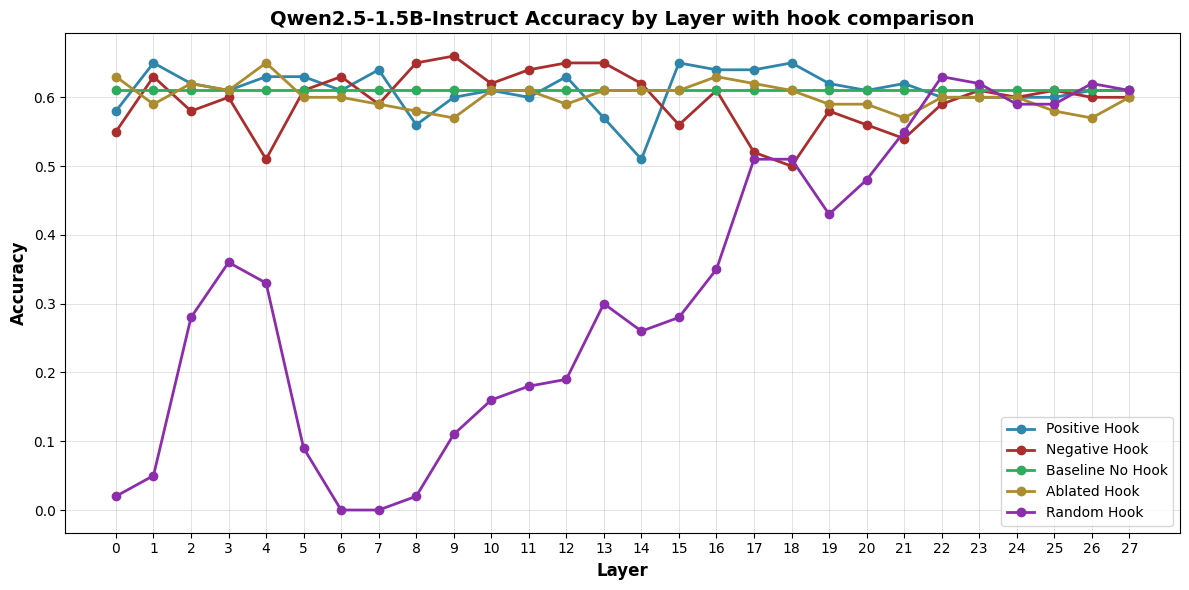

In [ ]:


# Filter data by hook type
df_baseline = df_15b[df_15b['notes'] == 'baseline accuracy per layer'].sort_values('layer')
df_positive = df_15b[df_15b['notes'] == 'positive hook accuracy per layer'].sort_values('layer')
df_negative = df_15b[df_15b['notes'] == 'negative hook accuracy per layer'].sort_values('layer')
df_ablated = df_15b[df_15b['notes'] == 'ablative hook accuracy per layer'].sort_values('layer')
df_random = df_15b[df_15b['notes'] == 'random hook accuracy per layer'].sort_values('layer')

model_name = df_15b['model_name'].iloc[0]

# Plot accuracy vs layer for both hook types
plt.figure(figsize=(12, 6))
plt.plot(df_positive['layer'], df_positive['value'], marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Positive Hook')
plt.plot(df_negative['layer'], df_negative['value'], marker='o', linewidth=2, markersize=6, color='#AB2E2E', label='Negative Hook')
plt.plot(df_baseline['layer'], df_baseline['value'], marker='o', linewidth=2, markersize=6, color='#2EAB5B', label='Baseline No Hook')
plt.plot(df_ablated['layer'], df_ablated['value'], marker='o', linewidth=2, markersize=6, color='#AB8C2E', label='Ablated Hook')
plt.plot(df_random['layer'], df_random['value'], marker='o', linewidth=2, markersize=6, color='#8C2EAB', label='Random Hook')
plt.xlabel("Layer", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')
plt.title(f"{model_name} Accuracy by Layer with hook comparison", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
plt.xticks(range(len(df_baseline['layer'])))
plt.tight_layout()
plt.legend()
plt.show()

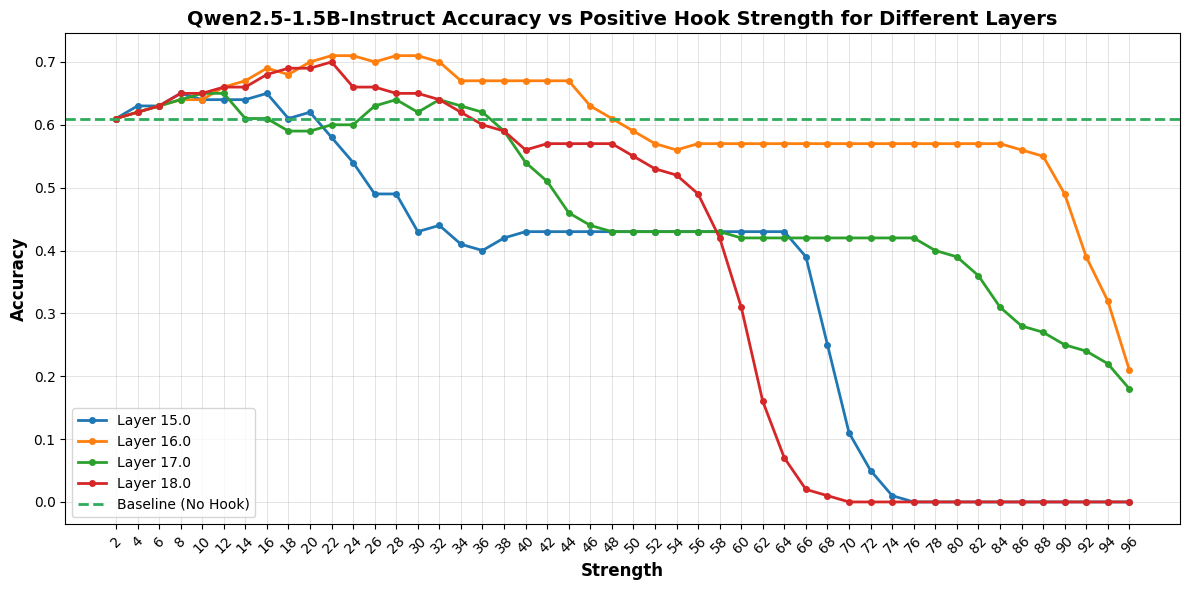

In [ ]:
# Filter for positive strength sweep data
df_strengths = df_15b[df_15b['hook_type'] == 'positive vector addition post attention']

# Get unique layers and strengths
layers = sorted(df_strengths['layer'].unique())
strengths = sorted(df_strengths['strength'].unique())

# Get baseline accuracy (average across all layers)
baseline_accuracy = df_15b[df_15b['notes'] == 'baseline accuracy per layer']['value'].mean()

model_name = df_15b['model_name'].iloc[0]

plt.figure(figsize=(12, 6))

for layer in layers:
    # Extract data for this layer
    layer_data = df_strengths[df_strengths['layer'] == layer].sort_values('strength')
    plt.plot(layer_data['strength'], layer_data['value'], marker='o', markersize=4, linewidth=2, label=f'Layer {layer}')

# Plot baseline as horizontal line
plt.axhline(y=baseline_accuracy, color='#2EAB5B', linestyle='--', linewidth=2, label='Baseline (No Hook)')

plt.xlabel("Strength", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')
plt.title(f"{model_name} Accuracy vs Positive Hook Strength for Different Layers", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
lr_data = df_strengths[df_strengths['layer'] == 16].sort_values('strength')
plt.xticks(lr_data['strength'],rotation=45)
plt.legend()
plt.tight_layout()
# plt.show()

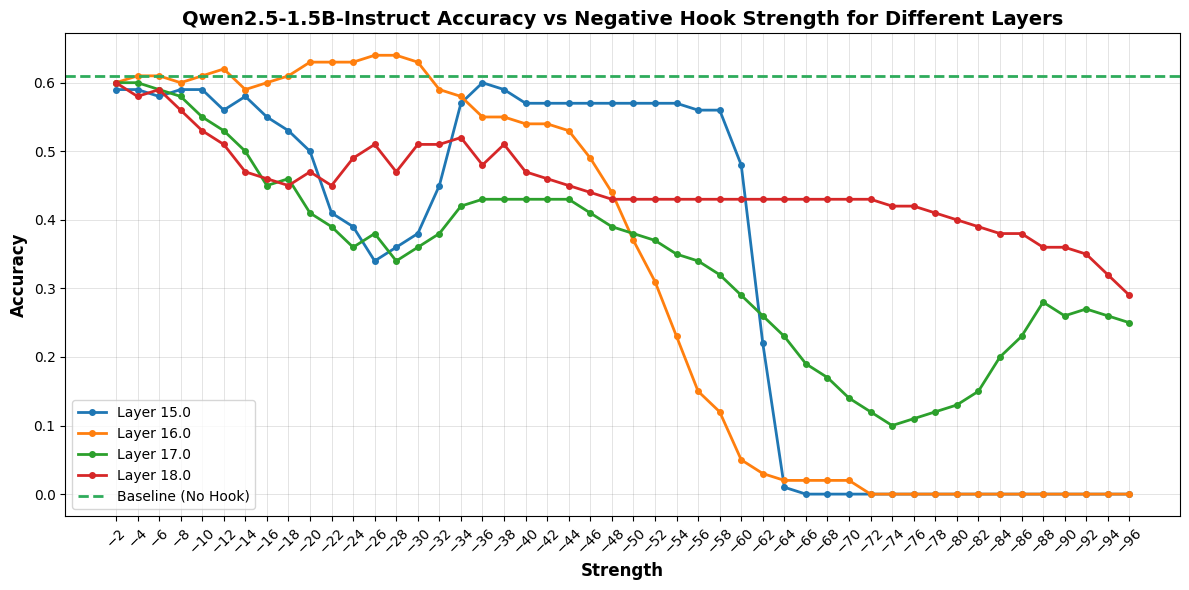

In [ ]:
# Filter for positive strength sweep data
df_strengths = df_15b[df_15b['notes'] == 'negative hook accuracy per strength per layer']

# Get unique layers and strengths
layers = sorted(df_strengths['layer'].unique())
strengths = sorted(df_strengths['strength'].unique())

model_name = df_15b['model_name'].iloc[0]

# Get baseline accuracy (average across all layers)
baseline_accuracy = df_15b[df_15b['notes'] == 'baseline accuracy per layer']['value'].mean()

plt.figure(figsize=(12, 6))

for layer in layers:
    # Extract data for this layer
    layer_data = df_strengths[df_strengths['layer'] == layer].sort_values('strength')
    plt.plot(layer_data['strength'], layer_data['value'], marker='o', markersize=4, linewidth=2, label=f'Layer {layer}')

# Plot baseline as horizontal line
plt.axhline(y=baseline_accuracy, color='#2EAB5B', linestyle='--', linewidth=2, label='Baseline (No Hook)')

plt.xlabel("Strength", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')
plt.title(f"{model_name} Accuracy vs Negative Hook Strength for Different Layers", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
r_data = df_strengths[df_strengths['layer'] == 16].sort_values('strength')
plt.xticks(r_data['strength'],rotation=45)
plt.gca().invert_xaxis()

plt.legend()
plt.tight_layout()
plt.show()

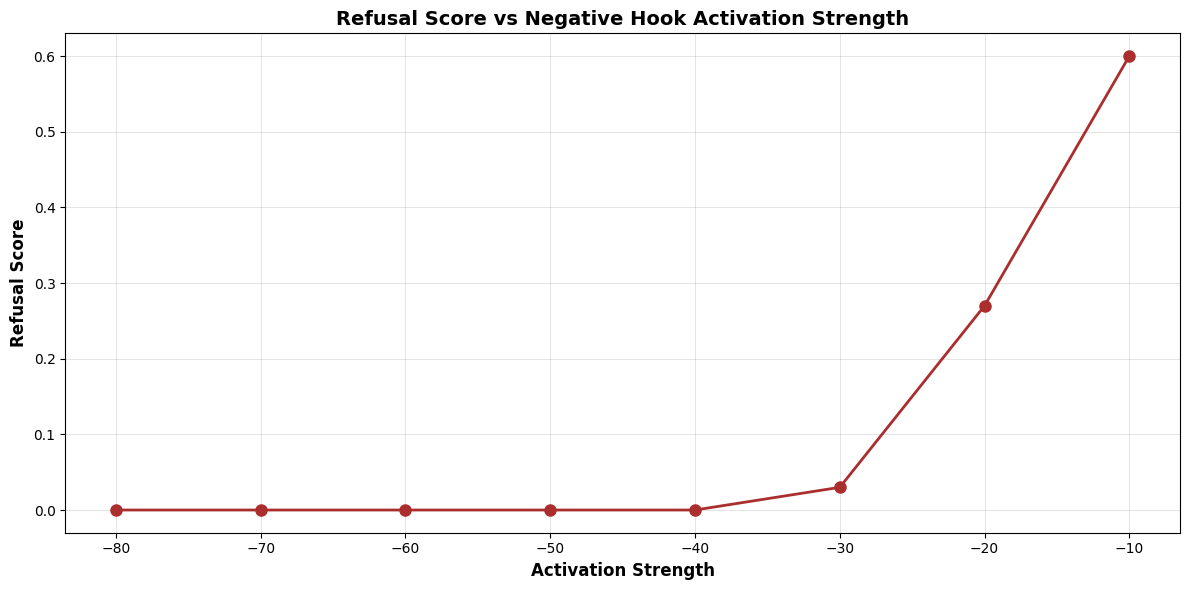

In [ ]:
# Filter for negative hook refusal score data
df_refusal = df[df['notes'] == 'negative hook refusal score per strength'].sort_values('strength')

plt.figure(figsize=(12, 6))
plt.plot(df_refusal['strength'], df_refusal['value'], marker='o', linewidth=2, markersize=8, color='#AB2E2E')
plt.xlabel("Activation Strength", fontsize=12, fontweight='bold')
plt.ylabel("Refusal Score", fontsize=12, fontweight='bold')
plt.title("Refusal Score vs Negative Hook Activation Strength", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 model_name        run_id  seed  \
333     Qwen2.5-7B-Instruct  1.767387e+09     0   
1226  Qwen2.5-1.5B-Instruct  1.767415e+09     0   

                                         hook_type  layer  strength  \
333   truth vector subtraction hook post attention   17.0     -43.0   
1226  truth vector subtraction hook post attention   17.0     -28.0   

             metric  value  batch_size dataset_slice  \
333   refusal score   0.00         100             :   
1226  refusal score   0.89         100             :   

                            notes  
333   negative hook refusal score  
1226  negative hook refusal score  


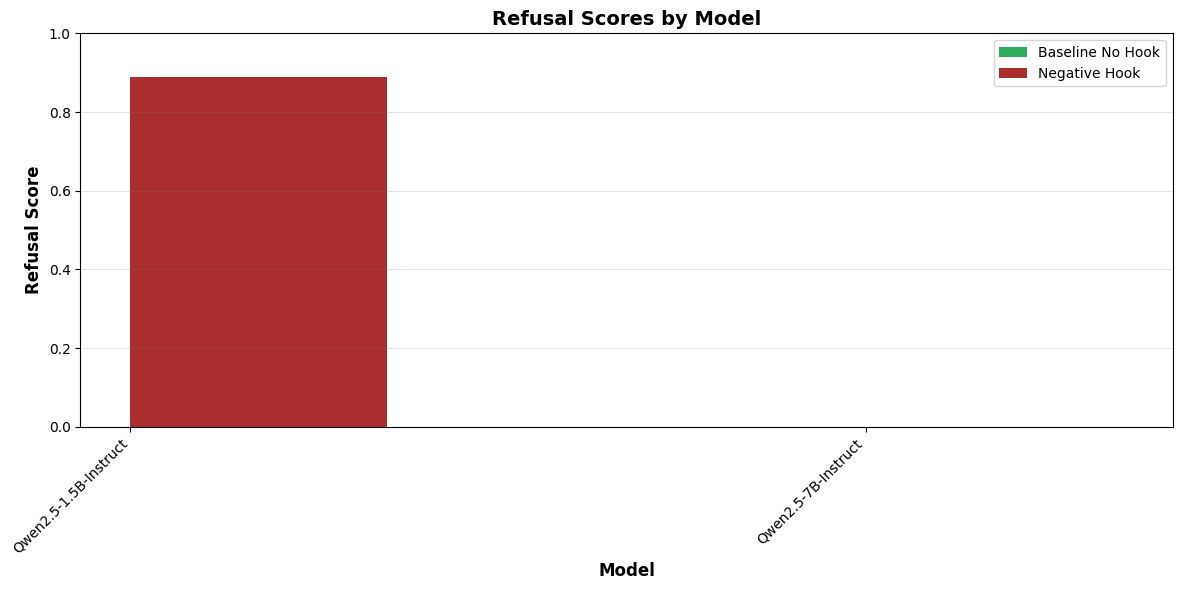

In [ ]:
# Histogram of refusal scores by model
# Uses two metrics: baseline no hook refusal vs negative hook refusal score
refusal_df_base = df[df['notes']=="Baseline no hook refusal score"]
refusal_df_neg = df[df['notes'] == "negative hook refusal score"]

# Get unique models
models = sorted(df['model_name'].unique())

# Extract values for each model
baseline_values = []
negative_values = []

for model in models:
    base_val = refusal_df_base[refusal_df_base['model_name'] == model]['value'].mean()
    neg_val = refusal_df_neg[refusal_df_neg['model_name'] == model]['value'].mean()
    baseline_values.append(base_val)
    negative_values.append(neg_val)

x = range(len(models))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - bar_width/2 for i in x], baseline_values,
        width=bar_width, color='#2EAB5B', label='Baseline No Hook')
plt.bar([i + bar_width/2 for i in x], negative_values,
        width=bar_width, color='#AB2E2E', label='Negative Hook')

plt.ylabel('Refusal Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Refusal Scores by Model', fontsize=14, fontweight='bold')
plt.xticks(x, models, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()